> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# Import fourier coefficients for amalytical solutions at the boundaries

import pickle

with open('../../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass


# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)


#-------- 1. Boundary Condition points used for Perturbation network --------
n_surface = len(ltst_surf)  # Should be 552


# Surface boundary (x=0). No perturbation on the surface temperature.:
t_bc_surface = random.uniform(key2, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))
u_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)


# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max

u_bc_bottom = jnp.zeros((n_surface, 1))  # (552, 1)

## Boudnaries at top and bottom of mole. mole is isothermal, so we will enforce the same temperature at the top and bottom of the mole. 

# Mole top boundary (z = z_0))
t_bc_mole_top = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_top = jnp.ones((len(ltst_mole), 1)) * z_0


# Mole bottom boundary (z = z_1))
t_bc_mole_bottom = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_bottom = jnp.ones((len(ltst_mole), 1)) * z_1


u_bc_mole = jnp.array(temp_mole).reshape(-1, 1)

#Join all bcs except the mole surface

t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])  

# 2. Physics collocation points (50 * 50 = 2500 points). Soil is only on the top and bottom
t_physics_top = random.uniform(key1, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_top = random.uniform(key2, (2500, 1), minval=0, maxval=z_0)

t_physics_bottom = random.uniform(key3, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_bottom = random.uniform(key4, (2500, 1), minval=z_1, maxval=z_max)

t_physics = jnp.concatenate([t_physics_top, t_physics_bottom])
x_physics = jnp.concatenate([x_physics_top, x_physics_bottom])

# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)

# Top region: z ∈ [0, z_0] → [0, 1]
def normalize_z_top(z): return z / z_0

# Bottom region: z ∈ [z_1, z_max] → [0, 1]  
def normalize_z_bottom(z): return (z - z_1) / (z_max - z_1)


# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)




t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(kappa)  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2

physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))

# Solve every point Analytacly using the Fourier series solution for the undisturbed soil temperature. 
def T_1D(A_n, phi_n, T_mean, N_harmonics, omega):
    """undisturbed soil temperature - Fourier Series"""
    n_vals = jnp.arange(1, N_harmonics + 1)
    An = A_n[1:N_harmonics + 1]
    phin = phi_n[1:N_harmonics + 1]

    @jit
    def T_analytical(t, z, kappa):
        # Skin depths recomputed each call using current kappa
        delta_n = jnp.sqrt(2 * kappa / (n_vals * omega))
        u_far = T_mean + jnp.sum(
            An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin)
        )

        return u_far

    return T_analytical


# Vectorize to handle all physics points at once

T_far = T_1D(
    jnp.array(coeffs['A_n']),
    jnp.array(coeffs['phi_n']),
    coeffs['T_mean'],
    coeffs['N_harmonics'],
    coeffs['omega']
)

T_sol_batch = vmap(T_far, in_axes=(0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 32, 32, 32, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={40000: 0.1, 80000: 0.01})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, 
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics, x_physics, kappa):

    def loss_fn(params):

        # 1. Boundary Condition Loss. Surfaceand bottom
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)

        u_pred_bc = network(params, tx_bc)
        bc_loss_edges = jnp.mean((u_pred_bc - u_bc)**2)

        # Boundary condition at mole surface (top
        u_pred_mole_top = network(params, jnp.concatenate([normalize_t(t_bc_mole_top), normalize_x(x_bc_mole_top)], axis=1))
        target_top = u_bc_mole - T_sol_batch(t_bc_mole_top.ravel(), x_bc_mole_top.ravel(), kappa).reshape(-1, 1)  # Subtract the undisturbed solution to get the perturbation target
        bc_loss_mole_top = jnp.mean((u_pred_mole_top - target_top)**2)  

        # Boundary condition at mole surface (bottom)
        u_pred_mole_bottom = network(params, jnp.concatenate([normalize_t(t_bc_mole_bottom), normalize_x(x_bc_mole_bottom)], axis=1))
        target_bottom = u_bc_mole - T_sol_batch(t_bc_mole_bottom.ravel(), x_bc_mole_bottom.ravel(), kappa).reshape(-1, 1)  # Subtract the undisturbed solution to get the perturbation target
        bc_loss_mole_bottom = jnp.mean((u_pred_mole_bottom - target_bottom)**2)


        bc_loss_mole = (bc_loss_mole_top + bc_loss_mole_bottom) 

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(),
                                                x_physics.ravel(),
                                                kappa)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        w_edges = 1.0
        w_mole = 1.0  
        w_phys = 1.0


        return  w_edges * bc_loss_edges  + w_phys * physics_loss + w_mole * bc_loss_mole , (bc_loss_edges, physics_loss, bc_loss_mole)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 100000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []



# Training loop
losses = []
losses_bc_edges = []
losses_phys = []
losses_bc_mole = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc, 
        t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
        t_physics, x_physics, kappa)

    losses.append(loss)
    losses_bc_edges.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_bc_mole.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"BC edges: {individual_loss[0]:.6f}")
        print(f"Physics:  {individual_loss[1]:.6f}")
        print(f"Data:  {individual_loss[2]:.6f}")




/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/100000, Loss: 440.056885
BC edges: 3.813190
Physics:  0.087728
BC mole:  436.155975
Iteration 2000/100000, Loss: 439.804779
BC edges: 4.019499
Physics:  0.052405
BC mole:  435.732880
Iteration 3000/100000, Loss: 439.644623
BC edges: 4.047194
Physics:  0.056321
BC mole:  435.541107
Iteration 4000/100000, Loss: 436.302429
BC edges: 4.208405
Physics:  0.552571
BC mole:  431.541443
Iteration 5000/100000, Loss: 414.884186
BC edges: 5.401294
Physics:  0.963176
BC mole:  408.519714
Iteration 6000/100000, Loss: 383.789917
BC edges: 8.677382
Physics:  3.993987
BC mole:  371.118561
Iteration 7000/100000, Loss: 360.113800
BC edges: 12.892753
Physics:  4.221951
BC mole:  342.999084
Iteration 8000/100000, Loss: 345.326965
BC edges: 16.485888
Physics:  4.779330
BC mole:  324.061737
Iteration 9000/100000, Loss: 333.635315
BC edges: 19.470757
Physics:  4.732901
BC mole:  309.431671
Iteration 10000/100000, Loss: 323.499451
BC edges: 22.421108
Physics:  4.906281
BC mole:  296.172058
Itera

## Use seperate networks one for each part of the soil

In [2]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# Import fourier coefficients for amalytical solutions at the boundaries

import pickle

with open('../../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass


# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)


#-------- 1. Boundary Condition points used for Perturbation network --------
n_surface = len(ltst_surf)  # Should be 552


# Surface boundary (x=0). No perturbation on the surface temperature.:
t_bc_surface = random.uniform(key2, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))
u_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)


# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max

u_bc_bottom = jnp.zeros((n_surface, 1))  # (552, 1)

## Boudnaries at top and bottom of mole. mole is isothermal, so we will enforce the same temperature at the top and bottom of the mole. 

# Mole top boundary (z = z_0))
t_bc_mole_top = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_top = jnp.ones((len(ltst_mole), 1)) * z_0


# Mole bottom boundary (z = z_1))
t_bc_mole_bottom = jnp.array(ltst_mole).reshape(-1, 1)# 5550 points from the mole temperature data
x_bc_mole_bottom = jnp.ones((len(ltst_mole), 1)) * z_1


u_bc_mole = jnp.array(temp_mole).reshape(-1, 1)

# #Join all bcs except the mole surface

# t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
# x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
# u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])  

# 2. Physics collocation points (50 * 50 = 2500 points). Soil is only on the top and bottom
t_physics_top = random.uniform(key1, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_top = random.uniform(key2, (2500, 1), minval=0, maxval=z_0)

t_physics_bottom = random.uniform(key3, (2500, 1), minval=0, maxval=sol_seconds)
x_physics_bottom = random.uniform(key4, (2500, 1), minval=z_1, maxval=z_max)

# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)

# Top region: z ∈ [0, z_0] → [0, 1]
def normalize_z_top(z): return z / z_0

# Bottom region: z ∈ [z_1, z_max] → [0, 1]  
def normalize_z_bottom(z): return (z - z_1) / (z_max - z_1)


# Normalize all data

t_bc_surface = normalize_t(t_bc_surface)
x_bc_surface = normalize_z_top(x_bc_surface)

t_bc_bottom = normalize_t(t_bc_bottom)
x_bc_bottom = normalize_z_bottom(x_bc_bottom)


t_physics_top = normalize_t(t_physics_top)
x_physics_top = normalize_z_top(x_physics_top)

t_physics_bottom = normalize_t(t_physics_bottom)
x_physics_bottom = normalize_z_bottom(x_physics_bottom)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

def normalize_kappa_top(kappa):
    return kappa * (t_max - t_min) / ((z_0)**2)

def normalize_kappa_bottom(kappa):
    return kappa * (t_max - t_min) / ((z_max - z_1)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        region: String indicating the region ('top' or 'bottom')
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)



    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)


    return du_dt / kappa - d2u_dx2

physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))

# Solve every point Analytacly using the Fourier series solution for the undisturbed soil temperature. 
def T_1D(A_n, phi_n, T_mean, N_harmonics, omega):
    """undisturbed soil temperature - Fourier Series"""
    n_vals = jnp.arange(1, N_harmonics + 1)
    An = A_n[1:N_harmonics + 1]
    phin = phi_n[1:N_harmonics + 1]

    @jit
    def T_analytical(t, z, kappa):
        # Skin depths recomputed each call using current kappa
        delta_n = jnp.sqrt(2 * kappa / (n_vals * omega))
        u_far = T_mean + jnp.sum(
            An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin)
        )

        return u_far

    return T_analytical


# Vectorize to handle all physics points at once

T_far = T_1D(
    jnp.array(coeffs['A_n']),
    jnp.array(coeffs['phi_n']),
    coeffs['T_mean'],
    coeffs['N_harmonics'],
    coeffs['omega']
)

T_sol_batch = vmap(T_far, in_axes=(0, 0, None))


# Initialize network
key = random.PRNGKey(123)
key, key1 = random.split(key)
layer_sizes = [2, 32, 32, 32, 1]  # 2 inputs (t, x), 1 output (u)
# Two networks, one per soil region
params_top = init_network_params(layer_sizes, key)
params_bot = init_network_params(layer_sizes, key1)

params = { 'top': params_top, 'bottom': params_bot }

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={40000: 0.1, 80000: 0.01})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom, u_bc_surface,
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom, kappa):

    def loss_fn(params):

        # 1. Boundary Condition Loss. Surfaceand bottom
        tx_bc_surface = jnp.concatenate([t_bc_surface, x_bc_surface], axis=1)
        tx_bc_bottom = jnp.concatenate([t_bc_bottom, x_bc_bottom], axis=1)

        u_pred_bc_surface = network(params['top'], tx_bc_surface)
        u_pred_bc_bottom = network(params['bottom'], tx_bc_bottom)
        bc_loss_edges = jnp.mean((u_pred_bc_surface - u_bc_surface)**2) + jnp.mean((u_pred_bc_bottom - u_bc_surface)**2)

        # Boundary condition at mole surface (top)
        u_pred_mole_top = network(params['top'], jnp.concatenate([normalize_t(t_bc_mole_top), normalize_z_top(x_bc_mole_top)], axis=1))
        T_1d_top = T_sol_batch(t_bc_mole_top.ravel(), x_bc_mole_top.ravel(), kappa).reshape(-1, 1)
        T_total_top = T_1d_top + u_pred_mole_top  # network already evaluated above

        # Boundary condition at mole surface (bottom)
        u_pred_mole_bottom = network(params['bottom'], jnp.concatenate([normalize_t(t_bc_mole_bottom), normalize_z_bottom(x_bc_mole_bottom)], axis=1))
        T_1d_bot = T_sol_batch(t_bc_mole_bottom.ravel(), x_bc_mole_bottom.ravel(), kappa).reshape(-1, 1)
        T_total_bot = T_1d_bot + u_pred_mole_bottom


        data_loss = jnp.mean((T_total_top - u_bc_mole)**2) + jnp.mean((T_total_bot - u_bc_mole)**2)

        # 2. Physics Loss
        kappa_top = normalize_kappa_top(kappa)
        kappa_bot = normalize_kappa_bottom(kappa)
        physics_residuals_top = physics_residual_batch(params['top'],
                                                t_physics_top.ravel(),
                                                x_physics_top.ravel(),
                                                kappa_top)
        physics_residuals_bottom = physics_residual_batch(params['bottom'],
                                                t_physics_bottom.ravel(),
                                                x_physics_bottom.ravel(),
                                                kappa_bot)
        physics_loss = jnp.mean(physics_residuals_top**2) + jnp.mean(physics_residuals_bottom**2) # Physics residual is of 10000 points.

        w_edges = 1.0
        w_data = 5.0  
        w_phys = 1.0


        return  w_edges * bc_loss_edges  + w_phys * physics_loss + w_data * data_loss , (bc_loss_edges, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 100000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []



# Training loop
losses = []
losses_bc_edges = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
                params, opt_state,
                t_bc_surface, x_bc_surface, t_bc_bottom, x_bc_bottom, u_bc_surface,
                t_bc_mole_top, x_bc_mole_top, t_bc_mole_bottom, x_bc_mole_bottom, u_bc_mole,
                t_physics_top, x_physics_top, t_physics_bottom, x_physics_bottom, kappa)

    losses.append(loss)
    losses_bc_edges.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"BC edges: {individual_loss[0]:.6f}")
        print(f"Physics:  {individual_loss[1]:.6f}")
        print(f"Data:  {individual_loss[2]:.6f}")



import pickle

forward_params = params  # your trained forward params
with open('forward_checkpoint/forward_warmstart_3.93e-8.pkl', 'wb') as f:
    pickle.dump(jax.device_get(forward_params), f)


/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/100000, Loss: 79.367477
BC edges: 7.165997
Physics:  7.049019
Data:  13.030494
Iteration 2000/100000, Loss: 2.690992
BC edges: 0.146550
Physics:  0.850829
Data:  0.338723
Iteration 3000/100000, Loss: 0.591772
BC edges: 0.037221
Physics:  0.276478
Data:  0.055615
Iteration 4000/100000, Loss: 0.251267
BC edges: 0.016658
Physics:  0.130779
Data:  0.020766
Iteration 5000/100000, Loss: 0.154261
BC edges: 0.010297
Physics:  0.095534
Data:  0.009686
Iteration 6000/100000, Loss: 0.109901
BC edges: 0.007281
Physics:  0.072906
Data:  0.005943
Iteration 7000/100000, Loss: 0.062745
BC edges: 0.005133
Physics:  0.038850
Data:  0.003753
Iteration 8000/100000, Loss: 0.051626
BC edges: 0.003715
Physics:  0.032276
Data:  0.003127
Iteration 9000/100000, Loss: 0.044267
BC edges: 0.002907
Physics:  0.027751
Data:  0.002722
Iteration 10000/100000, Loss: 0.063047
BC edges: 0.002256
Physics:  0.046294
Data:  0.002899
Iteration 11000/100000, Loss: 0.031252
BC edges: 0.001835
Physics:  0.016502


## Plots

### Loss curves

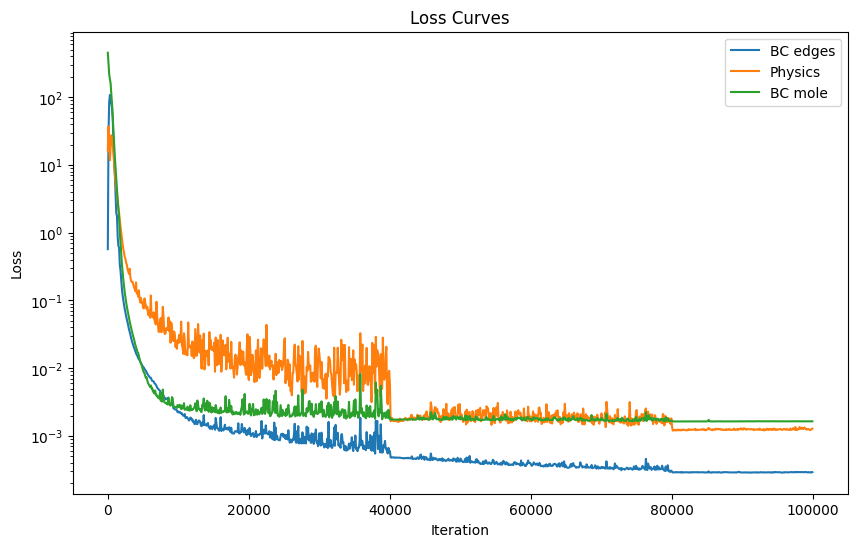

In [14]:
every = 100
iters = range(0, len(losses), every)
plt.figure(figsize=(10, 6))
plt.semilogy(list(iters), losses_bc_edges[::every], label='BC edges')
plt.semilogy(list(iters), losses_phys[::every], label='Physics')
plt.semilogy(list(iters), losses_bc_mole[::every], label='BC mole')
plt.legend(); plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.show()

### mole BC fit - does T_1D + T_pert = T_mole at z0 and z1?

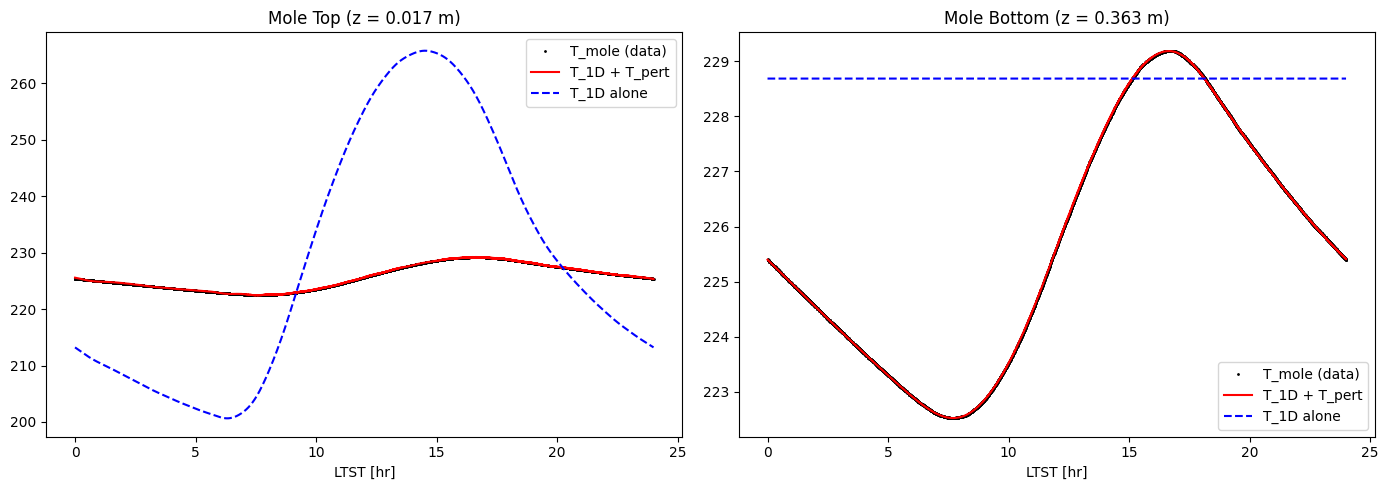

In [15]:
# Evaluate at mole top
t_eval = t_bc_mole_top.ravel()  # raw seconds
z_top_val = jnp.ones_like(t_eval) * z_0

T_1d_top = T_sol_batch(t_eval, z_top_val, kappa)
T_pert_top = network(params['top'], 
    jnp.concatenate([normalize_t(t_eval.reshape(-1,1)), 
                     normalize_z_top(z_top_val.reshape(-1,1))], axis=1)).ravel()
T_total_top = T_1d_top + T_pert_top

# Same for mole bottom
z_bot_val = jnp.ones_like(t_eval) * z_1
T_1d_bot = T_sol_batch(t_eval, z_bot_val, kappa)
T_pert_bot = network(params['bottom'],
    jnp.concatenate([normalize_t(t_eval.reshape(-1,1)),
                     normalize_z_bottom(z_bot_val.reshape(-1,1))], axis=1)).ravel()
T_total_bot = T_1d_bot + T_pert_bot

# Sort by time for clean plotting
idx = jnp.argsort(t_eval)
hours = t_eval[idx] * 24 / sol_seconds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hours, jnp.array(temp_mole)[idx], 'k.', ms=2, label='T_mole (data)')
axes[0].plot(hours, T_total_top[idx], 'r-', label='T_1D + T_pert')
axes[0].plot(hours, T_1d_top[idx], 'b--', label='T_1D alone')
axes[0].set_title(f'Mole Top (z = {z_0} m)'); axes[0].legend(); axes[0].set_xlabel('LTST [hr]')

axes[1].plot(hours, jnp.array(temp_mole)[idx], 'k.', ms=2, label='T_mole (data)')
axes[1].plot(hours, T_total_bot[idx], 'r-', label='T_1D + T_pert')
axes[1].plot(hours, T_1d_bot[idx], 'b--', label='T_1D alone')
axes[1].set_title(f'Mole Bottom (z = {z_1} m)'); axes[1].legend(); axes[1].set_xlabel('LTST [hr]')
plt.tight_layout(); plt.show()

### T_pert spatial profiles — does the perturbation go to zero at edges?

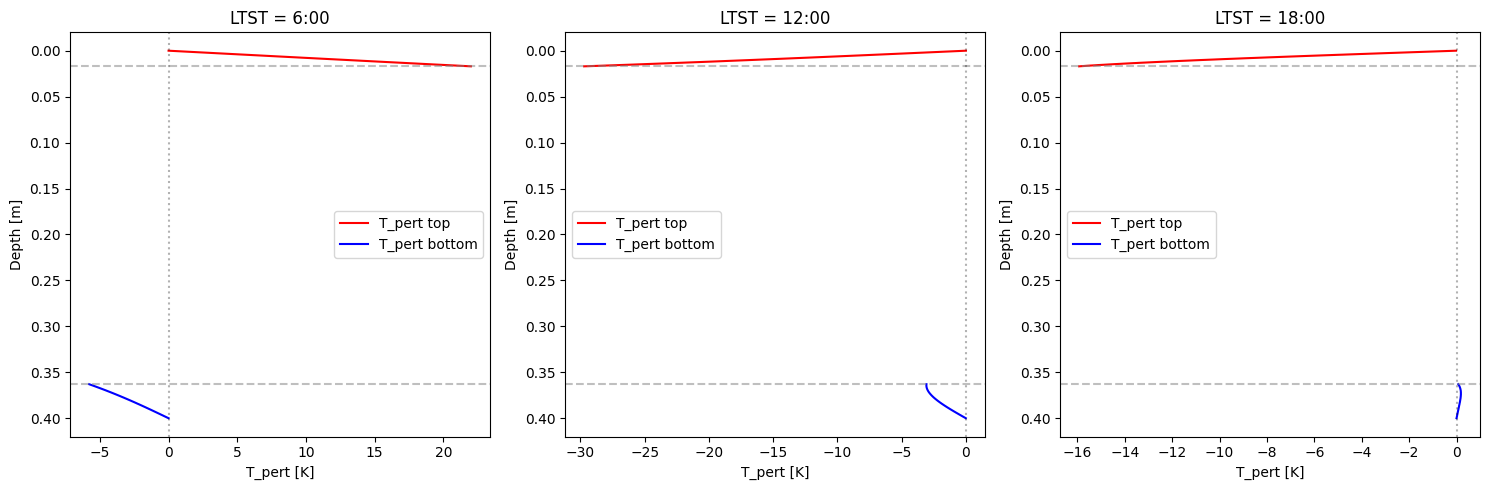

In [16]:
# Pick a few time snapshots
times_hr = [6, 12, 18]  # morning, noon, evening
z_dense_top = jnp.linspace(0, z_0, 100)
z_dense_bot = jnp.linspace(z_1, z_max, 100)

fig, axes = plt.subplots(1, len(times_hr), figsize=(5*len(times_hr), 5))
for ax, hr in zip(axes, times_hr):
    t_sec = hr * sol_seconds / 24
    t_norm_val = normalize_t(t_sec)
    
    # Top region
    inp_top = jnp.column_stack([jnp.full(100, t_norm_val), normalize_z_top(z_dense_top)])
    pert_top = network(params['top'], inp_top).ravel()
    
    # Bottom region  
    inp_bot = jnp.column_stack([jnp.full(100, t_norm_val), normalize_z_bottom(z_dense_bot)])
    pert_bot = network(params['bottom'], inp_bot).ravel()
    
    ax.plot(pert_top, z_dense_top, 'r-', label='T_pert top')
    ax.plot(pert_bot, z_dense_bot, 'b-', label='T_pert bottom')
    ax.axhline(z_0, color='gray', ls='--', alpha=0.5)
    ax.axhline(z_1, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='k', ls=':', alpha=0.3)
    ax.invert_yaxis()
    ax.set_xlabel('T_pert [K]'); ax.set_ylabel('Depth [m]')
    ax.set_title(f'LTST = {hr}:00'); ax.legend()
plt.tight_layout(); plt.show()

### Physics residual heatmap

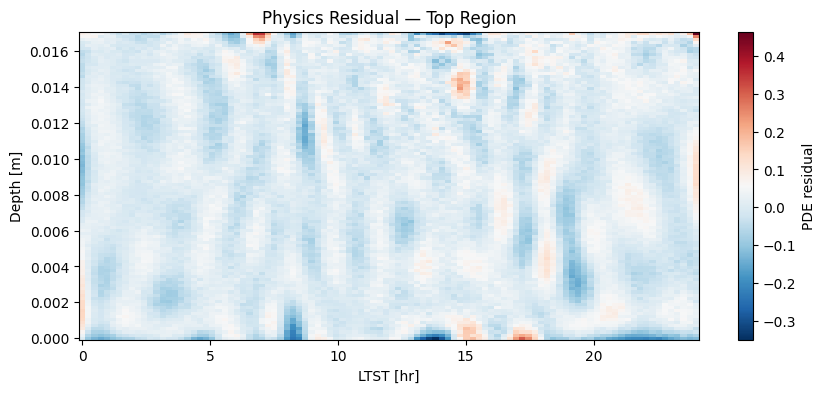

In [17]:
nt, nz = 100, 100
t_grid = jnp.linspace(0, 1, nt)  # already normalized
z_grid_top = jnp.linspace(0, 1, nz)  # already normalized

T, Z = jnp.meshgrid(t_grid, z_grid_top)
t_flat = T.ravel()
z_flat = Z.ravel()

kappa_top = normalize_kappa_top(kappa)
res_top = physics_residual_batch(params['top'], t_flat, z_flat, kappa_top)
res_map = res_top.reshape(nz, nt)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t_grid * 24, z_grid_top * z_0, res_map, cmap='RdBu_r', shading='auto')
plt.colorbar(label='PDE residual')
plt.xlabel('LTST [hr]'); plt.ylabel('Depth [m]')
plt.title('Physics Residual — Top Region')
plt.show()